In [ ]:
import numpy as np
import dpluspy
import pickle
import matplotlib.pyplot as plt

In [3]:
masks = [
    "intergenic",
    "10kb_exon_buffer",
    "20kb_exon_buffer",
    "50kb_exon_buffer",
    "1e-4M_exon_buffer"
]

In [ ]:
def run_bootstrap(in_fnames, out_fname):
    sums = {}
    for fname in in_fnames:
        with open(fname, "rb") as fin:
            chrom_sums = pickle.load(fin)
        sums.update(chrom_sums)

    bins = sums[next(iter(sums))]["bins"]
    pop_ids = sums[next(iter(sums))]["pop_ids"]

    replicates = dpluspy.bootstrapping.get_bootstrap_reps(
        sums, num_reps=100, weighted=True, aggregate=True)
    varcovs = dpluspy.bootstrapping.compute_varcovs(replicates)
    means = dpluspy.bootstrapping.weighted_means_across_regions(
        sums, aggregate=True)
    
    data = {
        "means": means, 
        "varcovs": varcovs, 
        "bins": bins, 
        "pop_ids": pop_ids,
        "replicates": replicates
    }
    with open(out_fname, "wb") as fout:
        pickle.dump(data, fout)
    return


for mask in masks:
    fnames = [f"data/sums/{mask}/sums_{mask}_chr{j}.pkl" for j in range(1, 23)]
    out_fname = f"data/stats/stats_{mask}.pkl"
    run_bootstrap(fnames, out_fname)

In [4]:
# Load statistics
pops_to_plot = ["Vindija", "Denisova", "UstIshim", "Yoruba1", "Yoruba3"]
means = []
varcovs = []

for mask in masks:
    fname = f"data/stats/stats_{mask}.pkl"
    pop_ids, bins, _means, _varcovs = dpluspy.inference.load_stats(
        fname, to_pops=pops_to_plot)
    means.append(_means)
    varcovs.append(_varcovs)

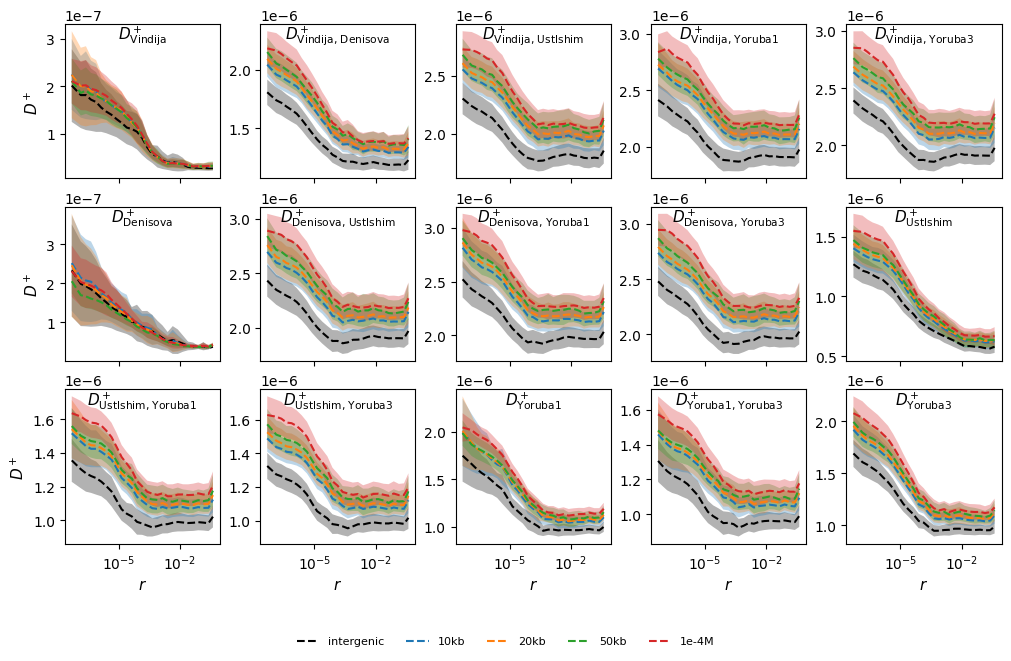

In [ ]:
# Plot a summary for five samples
colors = ["black", "tab:blue", "tab:orange", "tab:green", "tab:red"]
labels = ["intergenic", "10kb", "20kb", "50kb", "1e-4M"]
dpluspy.plotting.plot_D_plus_curves(means=means, varcovs=varcovs, bins=bins,
    pop_ids=pop_ids, labels=labels, colors=colors, 
    out="figures/fig_exon_buffer_summary.pdf",
    title="Exon buffers: summary")

In [18]:
# Load B-stratified statistics for comparison
B_means = []
B_varcovs = []
for quart in range(4):
    fname = f"../B_map_stratification/data/stats/stats_B_strat_quartile_{quart}.pkl"
    pop_ids, bins, _means, _varcovs = dpluspy.inference.load_stats(
        fname, to_pops=pops_to_plot)
    B_means.append(_means)
    B_varcovs.append(_varcovs)

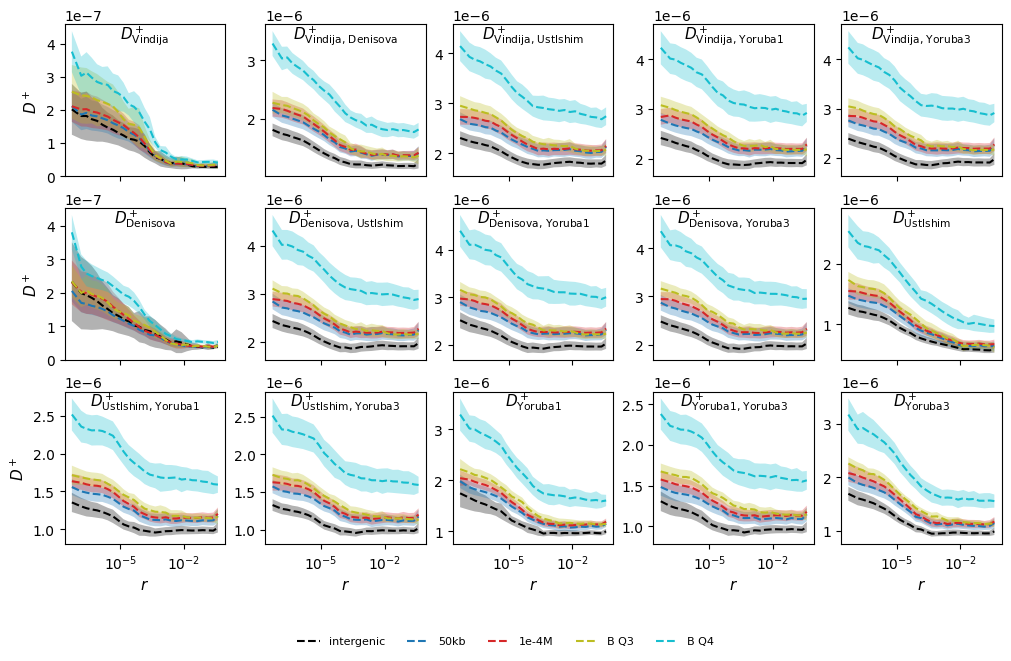

In [21]:
# Plot a summary for five samples
colors = ["black", "tab:blue", "tab:red", "tab:olive", "tab:cyan"]
labels = ["intergenic", "50kb", "1e-4M", "B Q3", "B Q4"]
dpluspy.plotting.plot_D_plus_curves(
    means=[means[0], means[3], means[4], B_means[2], B_means[3]], 
    varcovs=[varcovs[0], varcovs[3], varcovs[4], B_varcovs[2], B_varcovs[3]], 
    bins=bins, pop_ids=pop_ids, labels=labels, colors=colors, 
    out="figures/fig_B_quartile_comparison.pdf")

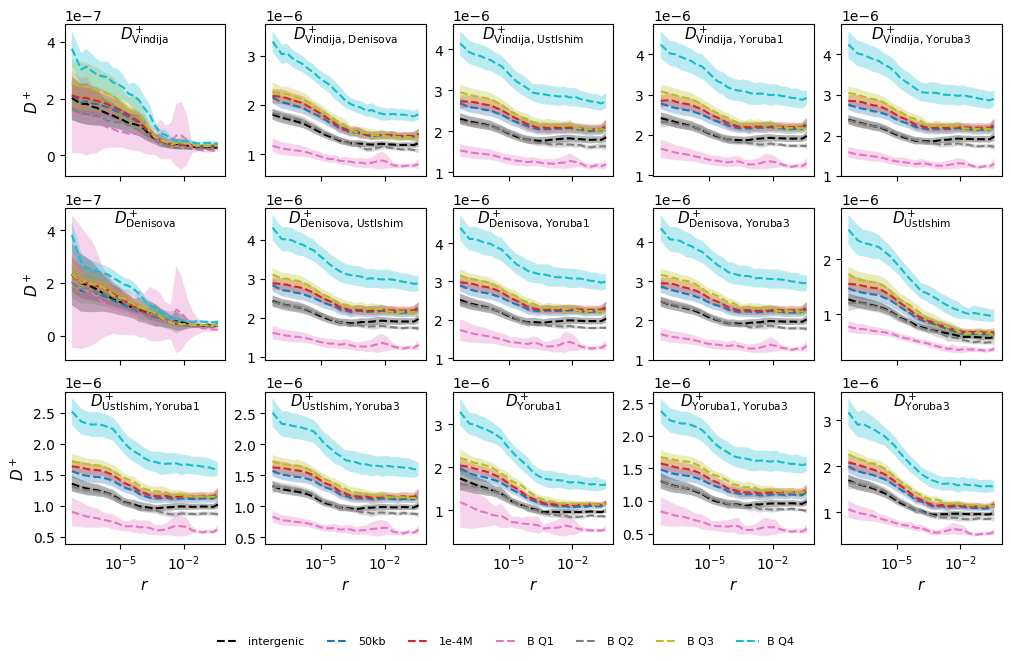

In [23]:
# Plot a summary for five samples
colors = ["black", "tab:blue", "tab:red", "tab:pink", "tab:grey", "tab:olive", "tab:cyan"]
labels = ["intergenic", "50kb", "1e-4M", "B Q1", "B Q2", "B Q3", "B Q4"]
dpluspy.plotting.plot_D_plus_curves(
    means=[means[0], means[3], means[4]] + B_means, 
    varcovs=[varcovs[0], varcovs[3], varcovs[4]] + B_varcovs, 
    bins=bins, pop_ids=pop_ids, labels=labels, colors=colors, 
    out="figures/fig_full_B_quartile_comparison.pdf")

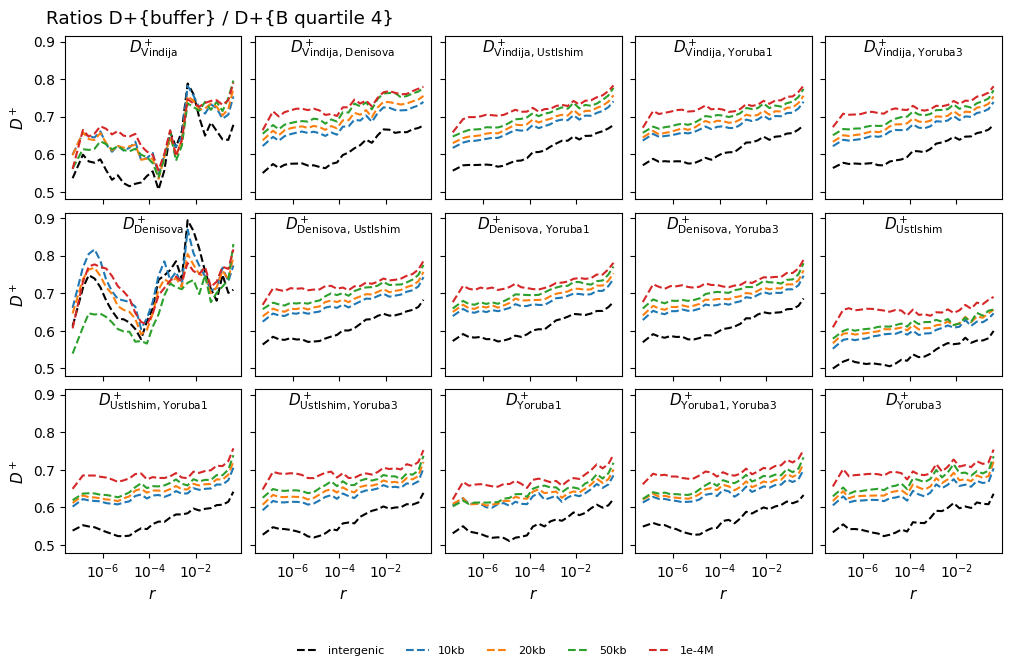

In [ ]:
# Plot the ratio D+_{buffer} / D+_{B quartile 4} for each buffer
# Varcovs are nonsensical here but are used because the plot func requires them
quartile4 = B_means[1]
ratios = []
for _means in means: 
    _ratios = [m1 / m0 for m1, m0 in zip(_means, quartile4)]
    ratios.append(_ratios)

colors = ["black", "tab:blue", "tab:orange", "tab:green", "tab:red"]
labels = ["intergenic", "10kb", "20kb", "50kb", "1e-4M"]
dpluspy.plotting.plot_D_plus_curves(
    means=ratios, varcovs=varcovs, sharey=True,
    bins=bins, pop_ids=pop_ids, labels=labels, colors=colors, 
    out="figures/fig_B_quartile4_ratio.pdf",
    title="Ratios D+{buffer} / D+{B quartile 4}")